In [17]:
from dataVisual import src_img_print,load_images,print_image
from pca import standarize,standarize_bulk,pca
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

PATH = './data/caras.csv'
df = pd.read_csv(PATH)

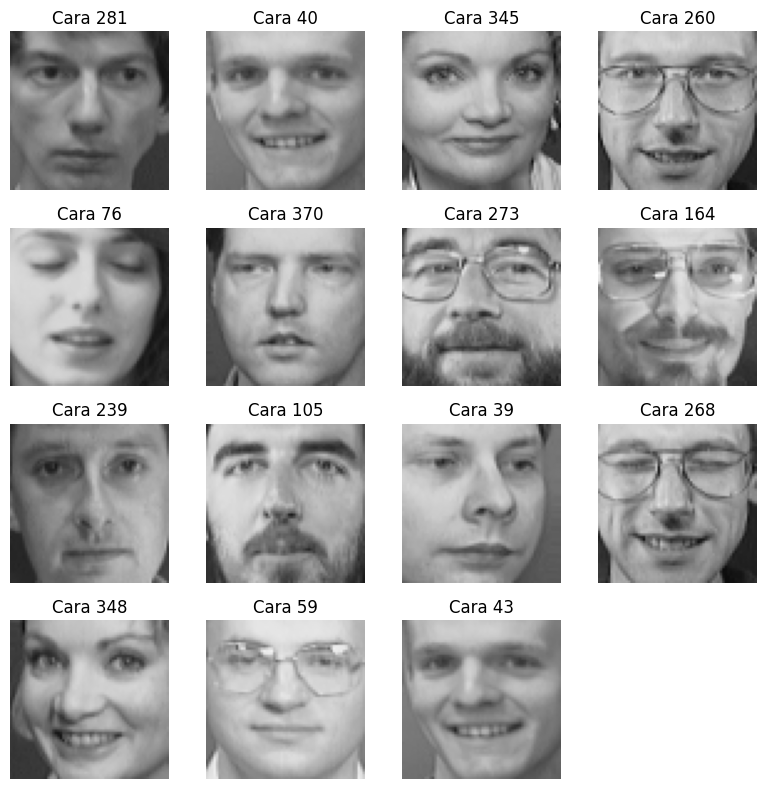

In [18]:
src_img_print(PATH,15)

In [19]:
persons_ids = df['person_id'].to_numpy(dtype=int)
persons = np.bincount(persons_ids)
print(persons_ids)
print(f"hay {len(persons)} personas distintas")
print(persons)

[ 0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  2  2  2  2
  2  2  2  2  2  2  3  3  3  3  3  3  3  3  3  3  4  4  4  4  4  4  4  4
  4  4  5  5  5  5  5  5  5  5  5  5  6  6  6  6  6  6  6  6  6  6  7  7
  7  7  7  7  7  7  7  7  8  8  8  8  8  8  8  8  8  8  9  9  9  9  9  9
  9  9  9  9 10 10 10 10 10 10 10 10 10 10 11 11 11 11 11 11 11 11 11 11
 12 12 12 12 12 12 12 12 12 12 13 13 13 13 13 13 13 13 13 13 14 14 14 14
 14 14 14 14 14 14 15 15 15 15 15 15 15 15 15 15 16 16 16 16 16 16 16 16
 16 16 17 17 17 17 17 17 17 17 17 17 18 18 18 18 18 18 18 18 18 18 19 19
 19 19 19 19 19 19 19 19 20 20 20 20 20 20 20 20 20 20 21 21 21 21 21 21
 21 21 21 21 22 22 22 22 22 22 22 22 22 22 23 23 23 23 23 23 23 23 23 23
 24 24 24 24 24 24 24 24 24 24 25 25 25 25 25 25 25 25 25 25 26 26 26 26
 26 26 26 26 26 26 27 27 27 27 27 27 27 27 27 27 28 28 28 28 28 28 28 28
 28 28 29 29 29 29 29 29 29 29 29 29 30 30 30 30 30 30 30 30 30 30 31 31
 31 31 31 31 31 31 31 31 32 32 32 32 32 32 32 32 32

Se puede ver que tengo 10 imagenes por cada una de las 40 personas, y estan ordenadas

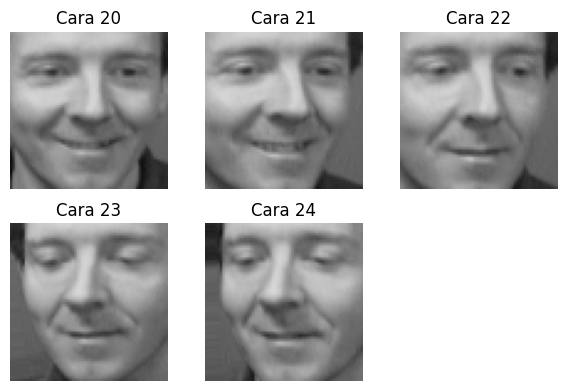

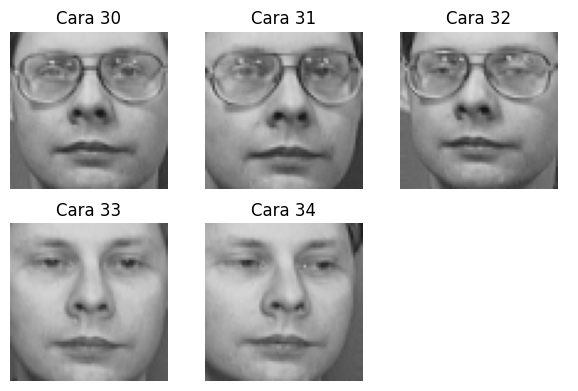

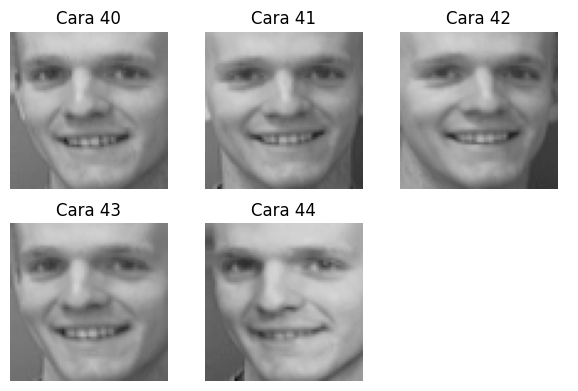

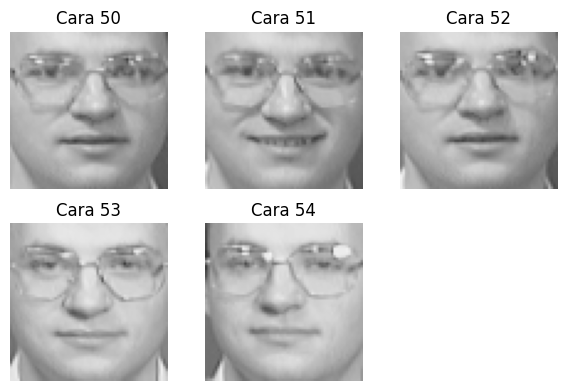

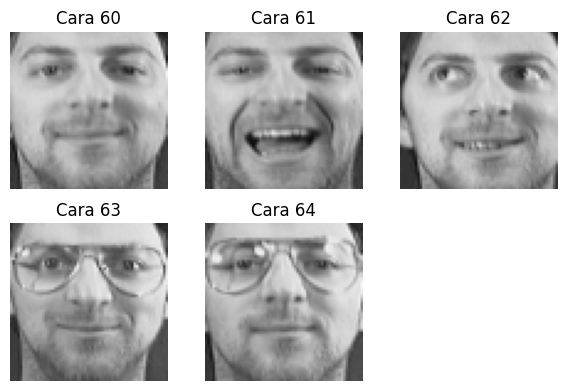

In [20]:
src_img_print(PATH,5,rand=False,start_id=2)
src_img_print(PATH,5,rand=False,start_id=3)
src_img_print(PATH,5,rand=False,start_id=4)
src_img_print(PATH,5,rand=False,start_id=5)
src_img_print(PATH,5,rand=False,start_id=6)

In [21]:
images = load_images(PATH,64)
print(f"cantidad total de imagenes: {len(images)}")
train = []
train_val = []
test = []
test_val = []
photo = 0
person = 0
for idx in range(len(images)):
        if photo < 2:
            test.append(images[idx])
            test_val.append(persons_ids[idx])
        else:
            train.append(images[idx])
            train_val.append(persons_ids[idx])
        photo = (photo+1)%10

full_test = list(zip(test,test_val))
random.shuffle(full_test)
# unzip into two lists (images and labels)
test, test_val = map(list, zip(*full_test))

full_train = list(zip(train,train_val))
random.shuffle(full_train)
# unzip into two lists (images and labels)
train, train_val = map(list, zip(*full_train))

print(f"tamano de train: {len(train)}\ntamano de test: {len(test)}")

cantidad total de imagenes: 400
tamano de train: 320
tamano de test: 80


Separe dos fotos de cada cara para test, El resto fue a train. y se mezclaron las ambos arreglos de caras.

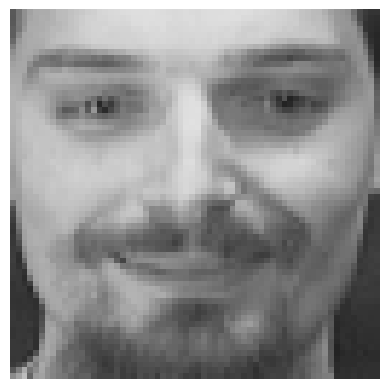

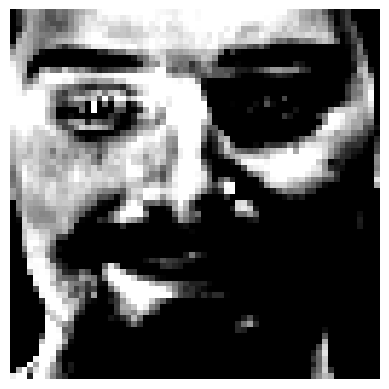

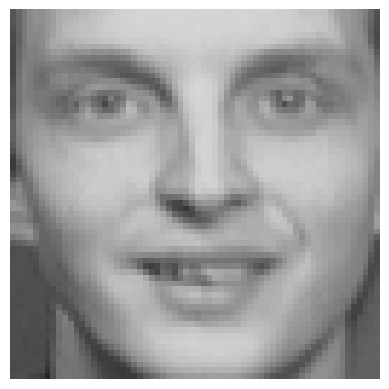

k=110 | MSE train=0.000998


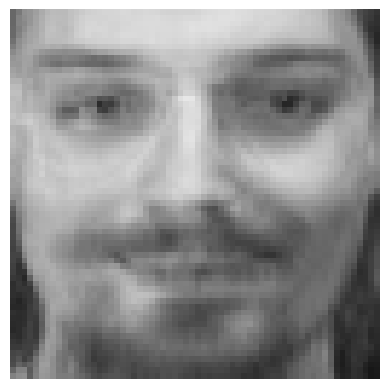

Imagen original:


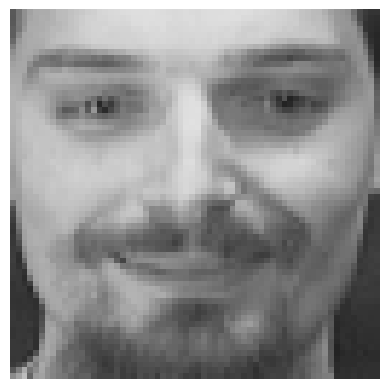

Imagen luego de PCA:


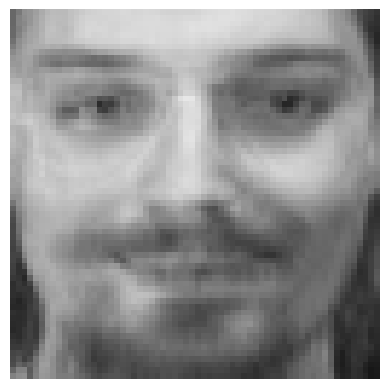

Varianza original: 4096.0
Varianza luego de PCA: 75.66744995117188
Porcentaje de varianza retenida luego de PCA: 1.8473498821258545%


In [22]:
mean = np.mean(train,axis=0)
std = np.std(train,axis=0)
print_image(train[0])
standarize(train[0],mean,std,print=True)
train_std = standarize_bulk(train,mean,std)
print_image(test[0])
compress_dataset = pca(train_std,train,mean,std)
print_image(compress_dataset[0])
#comparar el antes y el despues del pca en una imagen
print("Imagen original:")
print_image(train[0])
print("Imagen luego de PCA:")
print_image(compress_dataset[0])
#metrica para demostrar el cambio
original_var = np.var(train_std,axis=0).sum()
pca_var = np.var(compress_dataset,axis=0).sum()
print(f"Varianza original: {original_var}\nVarianza luego de PCA: {pca_var}")
print(f"Porcentaje de varianza retenida luego de PCA: {pca_var/original_var*100}%")


Componentes necesarios para ≥90% de la varianza: 62
Varianza acumulada con 62 componentes: 0.9012


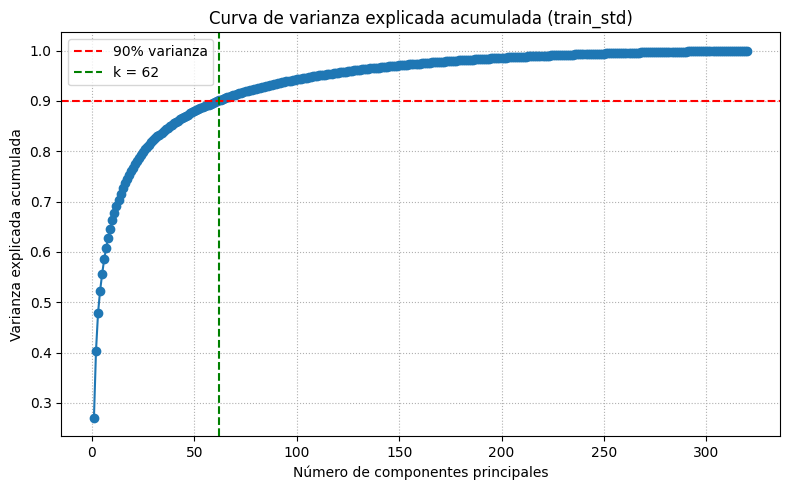

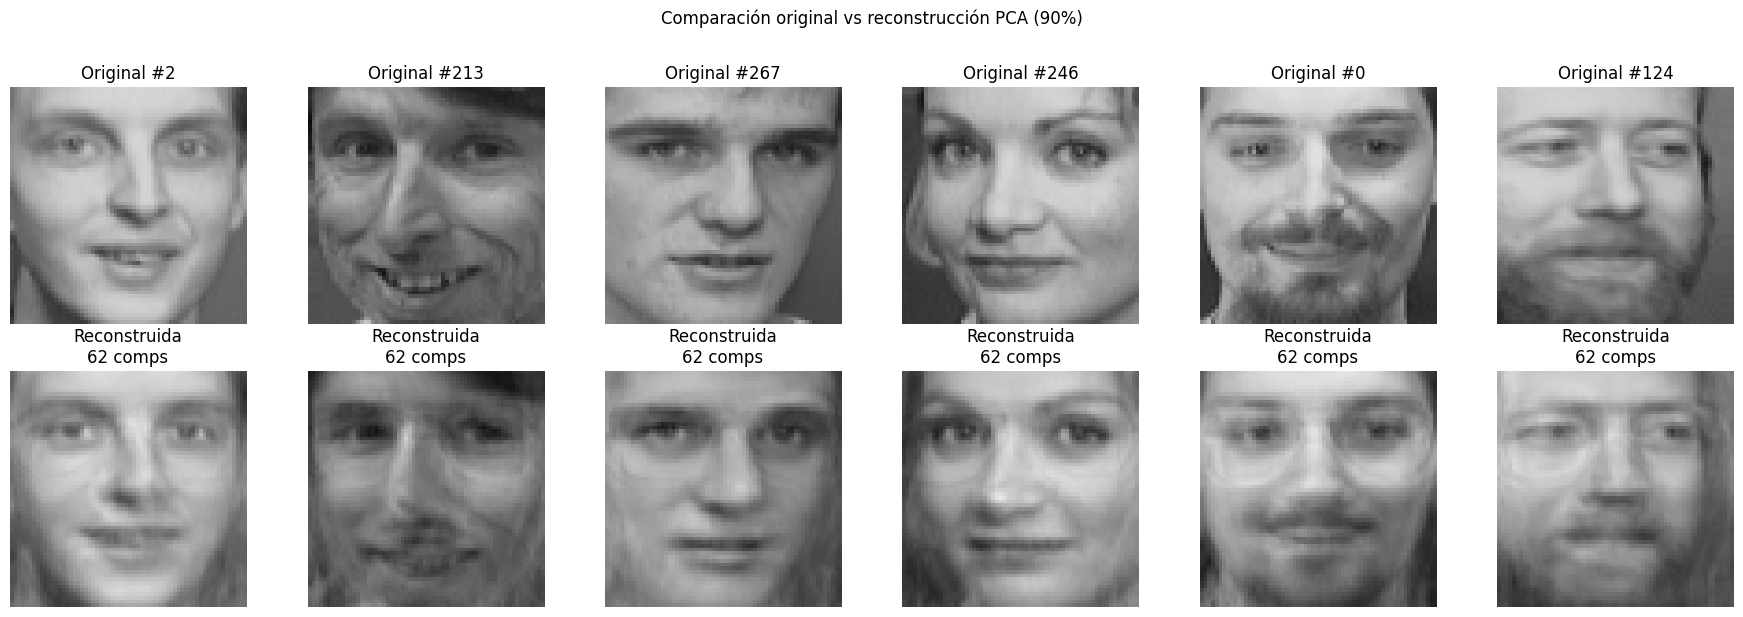

In [23]:
# Cálculo de la varianza explicada acumulada
X = train_std.reshape(len(train_std), -1)
n_samples = X.shape[0]

U, S, Vt = np.linalg.svd(X, full_matrices=False)
explained_variance = (S ** 2) / (n_samples - 1)
explained_ratio = explained_variance / explained_variance.sum()
cumulative_ratio = np.cumsum(explained_ratio)

k_90 = np.searchsorted(cumulative_ratio, 0.90) + 1
print(f"Componentes necesarios para ≥90% de la varianza: {k_90}")
print(f"Varianza acumulada con {k_90} componentes: {cumulative_ratio[k_90-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cumulative_ratio) + 1), cumulative_ratio, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% varianza")
plt.axvline(k_90, color="green", linestyle="--", label=f"k = {k_90}")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Curva de varianza explicada acumulada (train_std)")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

# Reconstrucción con k componentes
Wk = Vt[:k_90].T
Z = X @ Wk
X_rec_std = Z @ Wk.T

mean_flat = mean.reshape(-1)
std_flat = np.where(std.reshape(-1) == 0, 1.0, std.reshape(-1))
X_rec = (X_rec_std * std_flat) + mean_flat
train_rec = X_rec.reshape((-1,) + mean.shape)

# Comparativa visual (función de 1.a → uso de matplotlib/print_image)
muestras = np.random.choice(len(train), size=6, replace=False)

fig, axes = plt.subplots(2, len(muestras), figsize=(3 * len(muestras), 6))
for col, idx in enumerate(muestras):
    axes[0, col].imshow(train[idx], cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"Original #{idx}")
    axes[0, col].axis("off")

    axes[1, col].imshow(train_rec[idx], cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title(f"Reconstruida\n{k_90} comps")
    axes[1, col].axis("off")

plt.suptitle("Comparación original vs reconstrucción PCA (90%)", y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# --- Guardar el modelo PCA (parámetros) ---
#
# Esta celda guarda las variables clave que definen tu transformación PCA
# en un solo archivo comprimido (.npz) usando NumPy.
#
# Variables a guardar:
#   - mean: La imagen media de 'train' (ej: forma (64, 64))
#   - std:  La imagen de desv. estándar de 'train' (ej: forma (64, 64))
#   - Wk:   La matriz de componentes principales (ej: forma (4096, 62))
#   - k:    El número de componentes guardados (ej: 62)

try:
    # Verificamos las formas de lo que vamos a guardar
    print(f"Preparando para guardar el modelo PCA...")
    print(f" - Forma de 'mean': {mean.shape}")
    print(f" - Forma de 'std': {std.shape}")
    print(f" - Forma de 'Wk' (componentes): {Wk.shape}")
    print(f" - Número de componentes 'k': {k_90}")

    # Guardamos los arrays en un archivo .npz
    np.savez(
        'modelo_pca.npz',
        mean=mean,
        std=std,
        Wk=Wk,
        k=k_90
    )
    
    print("\n¡Éxito!")
    print("El modelo PCA se ha guardado correctamente en 'modelo_pca.npz'")
    print("Este archivo contiene 4 arrays: 'mean', 'std', 'Wk' y 'k'")

except NameError as e:
    print(f"¡ERROR DE EJECUCIÓN!")
    print(f"No se pudo encontrar una de las variables: {e}")
    print("Asegúrate de haber ejecutado la celda de cálculo de PCA primero.")
except Exception as e:
    print(f"Ocurrió un error inesperado al guardar: {e}")

Preparando para guardar el modelo PCA...
 - Forma de 'mean': (64, 64)
 - Forma de 'std': (64, 64)
 - Forma de 'Wk' (componentes): (4096, 62)
 - Número de componentes 'k': 62

¡Éxito!
El modelo PCA se ha guardado correctamente en 'modelo_pca.npz'
Este archivo contiene 4 arrays: 'mean', 'std', 'Wk' y 'k'


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np # Asegúrate de tenerlo importado

# --- OPTIMIZACIÓN DE HARDWARE (CUDA) ---
# 1. Detectar tu GPU (RTX 3070)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo seleccionado: {device}")
if torch.cuda.is_available():
    print(f"Nombre de la GPU: {torch.cuda.get_device_name(0)}")

# 2. Preparar el GradScaler para Automatic Mixed Precision (AMP)
# Esto activa tus TENSOR CORES para un entrenamiento mucho más rápido (FP16/FP32)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
print(f"Automatic Mixed Precision (AMP) activado: {scaler.is_enabled()}")

Dispositivo seleccionado: cuda
Nombre de la GPU: NVIDIA GeForce RTX 3070
Automatic Mixed Precision (AMP) activado: True


C:\Users\santi\AppData\Local\Temp\ipykernel_23080\1960025401.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


In [26]:
# --- OPTIMIZACIÓN DE ARQUITECTURA (CONVOLUCIONAL) ---
#
# CORRECCIÓN: Se elimina la capa final nn.Sigmoid() del decoder
# para permitir que el modelo genere valores negativos y positivos,
# coincidiendo con los datos estandarizados (train_std).
#
class ConvolutionalAutoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(ConvolutionalAutoencoder, self).__init__()
        
        # --- Encoder ---
        self.encoder_conv = nn.Sequential(
            # Input: (N, 1, 64, 64)
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # -> (N, 16, 32, 32)
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # -> (N, 32, 16, 16)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> (N, 64, 8, 8)
            nn.ReLU()
        )
        
        # Capa lineal para el espacio latente
        self.encoder_fc = nn.Linear(64 * 8 * 8, latent_dim) # 64*8*8 = 4096
        
        # --- Decoder ---
        self.decoder_fc = nn.Linear(latent_dim, 64 * 8 * 8)
        
        self.decoder_conv = nn.Sequential(
            # Input: (N, 64, 8, 8)
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> (N, 32, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # -> (N, 16, 32, 32)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1) # -> (N, 1, 64, 64)
            # nn.Sigmoid() <-- ¡ELIMINADA! Esta era la causa del error.
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1) # Aplanar: (N, 64, 8, 8) -> (N, 4096)
        encoded = self.encoder_fc(x)
        return encoded

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(x.size(0), 64, 8, 8) # Reformar: (N, 4096) -> (N, 64, 8, 8)
        decoded = self.decoder_conv(x)
        return decoded

    def forward(self, x):
        encoded = self.encode(x)
        decoded = self.decode(encoded)
        return decoded

In [27]:
# --- Celda 3: Preparación de Datos (Optimizada) ---

# 1. CÁLCULO DE 'test_std' (¡El paso que faltaba!)
# Debemos estandarizar 'test' usando la 'mean' y 'std' de 'train'.
# Asumimos que 'test', 'mean', y 'std' existen de tus celdas anteriores.

try:
    # Replicamos la lógica de estandarización segura (para evitar división por cero)
    # que se usó (o debió usar) para crear 'train_std'.
    # Asumimos que 'mean' y 'std' tienen forma (64, 64)
    std_safe = np.where(std == 0, 1.0, std)
    test_std = (test - mean) / std_safe
    
    print(f"Variable 'test_std' creada exitosamente. Forma: {test_std.shape}")

except NameError as e:
    print(f"¡ERROR! No se pudo crear 'test_std'. Falta una variable: {e}")
    print("Por favor, asegúrate de haber corrido las celdas donde defines 'test', 'mean', y 'std'.")
    raise e


# --- OPTIMIZACIÓN DE HARDWARE (CPU/DATALOADER) ---

# 2. Reformar datos a (N, Canales, Alto, Ancho) -> (N, 1, 64, 64)
# 'train_std' ya existe, y 'test_std' lo acabamos de crear.
X_train_tensor = torch.tensor(train_std, dtype=torch.float32).unsqueeze(1) # Añade dimensión de canal
X_test_tensor = torch.tensor(test_std, dtype=torch.float32).unsqueeze(1) # Añade dimensión de canal

# 3. Crear TensorDataset (El AE se entrena para reconstruirse a sí mismo)
train_tensor_dataset = TensorDataset(X_train_tensor, X_train_tensor)
test_tensor_dataset = TensorDataset(X_test_tensor, X_test_tensor)

# 4. Crear DataLoaders (Optimizados para tu hardware)
BATCH_SIZE = 32
loader_args = {
    'batch_size': BATCH_SIZE,
    'num_workers': 8,  # Bueno para tu Ryzen 5 (prueba 8 o 12)
    'pin_memory': True # Acelera la transferencia CPU -> GPU
}

train_loader = DataLoader(train_tensor_dataset, shuffle=True, **loader_args)
test_loader = DataLoader(test_tensor_dataset, shuffle=False, **loader_args)

print(f"\nDataLoaders listos con {loader_args['num_workers']} workers.")
print(f"Forma de los datos de entrenamiento: {X_train_tensor.shape}")
print(f"Forma de los datos de prueba: {X_test_tensor.shape}")

Variable 'test_std' creada exitosamente. Forma: (80, 64, 64)

DataLoaders listos con 8 workers.
Forma de los datos de entrenamiento: torch.Size([320, 1, 64, 64])
Forma de los datos de prueba: torch.Size([80, 1, 64, 64])


In [28]:
LATENT_DIM = k_90 
model_ae = ConvolutionalAutoencoder(latent_dim=LATENT_DIM).to(device) # <--- .to(device)

criterion = nn.MSELoss() 
optimizer = optim.Adam(model_ae.parameters(), lr=1e-3)

print(f"Autoencoder CONVOLUCIONAL creado con {LATENT_DIM} dimensiones latentes.")
print(f"Modelo movido a: {next(model_ae.parameters()).device}")

Autoencoder CONVOLUCIONAL creado con 62 dimensiones latentes.
Modelo movido a: cuda:0


In [29]:
# --- Celda 5: Loop de Entrenamiento (con API de AMP actualizada) ---

NUM_EPOCHS = 50 
train_losses = []
test_losses = []

print("Iniciando entrenamiento...")
for epoch in range(NUM_EPOCHS):
    # --- Entrenamiento ---
    model_ae.train()
    running_train_loss = 0.0
    
    for (inputs, targets) in train_loader:
        # 1. Mover datos a la GPU
        inputs, targets = inputs.to(device), targets.to(device)
        
        # 2. Forward pass con Mixed Precision (autocast)
        # --- CAMBIO AQUÍ ---
        # Usamos la nueva API 'torch.amp.autocast'
        with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == 'cuda')):
            outputs = model_ae(inputs)
            loss = criterion(outputs, targets)
        
        # 3. Limpiar gradientes
        optimizer.zero_grad()
        
        # 4. Backward pass (usando el Scaler)
        scaler.scale(loss).backward()
        
        # 5. Optimización (usando el Scaler)
        scaler.step(optimizer)
        
        # 6. Actualizar el Scaler
        scaler.update()
        
        running_train_loss += loss.item() * inputs.size(0)
    
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # --- Validación (en Test) ---
    model_ae.eval()
    running_test_loss = 0.0
    with torch.no_grad(): # No calculamos gradientes
        for (inputs, targets) in test_loader:
            # 1. Mover datos a la GPU
            inputs, targets = inputs.to(device), targets.to(device)
            
            # 2. Forward pass con Mixed Precision
            # --- CAMBIO AQUÍ ---
            # Usamos la nueva API 'torch.amp.autocast'
            with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == 'cuda')):
                outputs = model_ae(inputs)
                loss = criterion(outputs, targets)
                
            running_test_loss += loss.item() * inputs.size(0)
            
    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {epoch_train_loss:.6f} | Test Loss: {epoch_test_loss:.6f}')

print("¡Entrenamiento completado!")

Iniciando entrenamiento...
Epoch [5/50] | Train Loss: 0.570432 | Test Loss: 0.530503
Epoch [10/50] | Train Loss: 0.336523 | Test Loss: 0.329612
Epoch [15/50] | Train Loss: 0.249808 | Test Loss: 0.257406
Epoch [20/50] | Train Loss: 0.206548 | Test Loss: 0.226102
Epoch [25/50] | Train Loss: 0.177290 | Test Loss: 0.206496
Epoch [30/50] | Train Loss: 0.157491 | Test Loss: 0.193450
Epoch [35/50] | Train Loss: 0.141947 | Test Loss: 0.183851
Epoch [40/50] | Train Loss: 0.131087 | Test Loss: 0.179337
Epoch [45/50] | Train Loss: 0.121335 | Test Loss: 0.176227
Epoch [50/50] | Train Loss: 0.112567 | Test Loss: 0.172527
¡Entrenamiento completado!


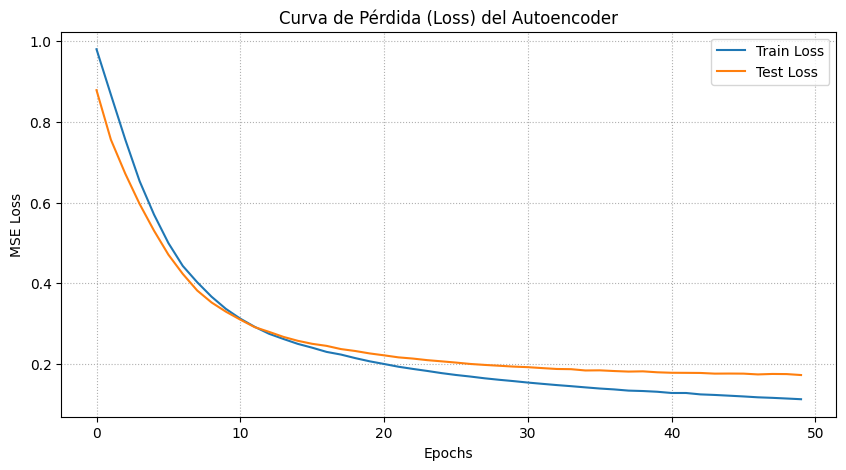

In [30]:
# Gráfico de la pérdida (Loss)
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Curva de Pérdida (Loss) del Autoencoder')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle=":")
plt.show()
